# DigiID — Entraînement du modèle de scoring

Notebook d'entraînement, d'évaluation et d'export du modèle ML
qui calcule le score de confiance DigiID.

## Démarche scientifique

1. **Génération synthétique** — 10 000 profils utilisateurs représentatifs
   du contexte ouest-africain (mobile money, SIM ancienne, etc.)
2. **Construction de la variable cible** — un score « vérité terrain »
   calculé à partir des règles métier du Cahier des Charges
3. **Séparation train/test** (80/20)
4. **Entraînement de 3 modèles** : Régression linéaire (baseline), 
   Random Forest, XGBoost
5. **Évaluation** — MAE, RMSE, R² sur le set de test
6. **Comparaison des performances**
7. **Export du meilleur modèle** au format joblib pour usage en production

## Auteur
ABOUDOU TRAORE Nihad — ISM Dakar — Mastère Stratégie Digitale 2025-2026

## 1. Installation et imports

In [1]:
# Si nécessaire, décommenter pour installer les dépendances
# %pip install pandas numpy scikit-learn xgboost matplotlib seaborn joblib faker

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Modèles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Évaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Export
import joblib

# Reproductibilité
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Style des graphiques
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)

print('Tous les imports OK')

Tous les imports OK


## 2. Génération de 10 000 profils synthétiques

On simule une population réaliste, avec les distributions calibrées sur les
données ANSD (Sénégal) et GSMA Mobile Money 2024.

**Hypothèses** :
- 70 % des utilisateurs ont une SIM ancienne (> 24 mois)
- 80 % utilisent activement le mobile money (Wave, Orange Money, etc.)
- Forte stabilité géographique (population urbaine, peu mobile)
- Réseaux de contacts variables (50 à 300 contacts)

In [3]:
NB_PROFILS = 10_000

rng = np.random.default_rng(RANDOM_SEED)

# --- Famille SIM ---
# Distribution bimodale : nouveaux (0-12 mois) + anciens (24-96 mois)
anciennete_sim_mois = np.concatenate([
    rng.integers(0, 12, size=int(NB_PROFILS * 0.3)),       # 30 % nouveaux
    rng.integers(24, 96, size=int(NB_PROFILS * 0.7)),      # 70 % anciens
])
rng.shuffle(anciennete_sim_mois)
anciennete_sim_mois = anciennete_sim_mois[:NB_PROFILS]

nombre_changements_sim = rng.integers(0, 5, size=NB_PROFILS)
operateur_stable = rng.random(size=NB_PROFILS) > 0.2  # 80 % stables

# --- Famille mobile money ---
# Loi log-normale : majoritairement entre 20 et 100 tx/mois, avec une queue
transactions_par_mois = np.clip(
    rng.lognormal(mean=np.log(40), sigma=0.7, size=NB_PROFILS), 0, 300
).astype(int)

montant_moyen = rng.integers(3000, 25000, size=NB_PROFILS)
regularite_temporelle = np.clip(rng.beta(a=4, b=2, size=NB_PROFILS), 0, 1)
diversite_partenaires = rng.integers(3, 20, size=NB_PROFILS)

# --- Famille géographie ---
nombre_mois_meme_ville = rng.integers(0, 60, size=NB_PROFILS)
nombre_changements_quartier = rng.integers(0, 4, size=NB_PROFILS)

# --- Famille réseau ---
taille_repertoire = rng.integers(50, 350, size=NB_PROFILS)
# Contacts anciens : 40-80% du répertoire
ratios_anciens = rng.uniform(0.4, 0.85, size=NB_PROFILS)
contacts_anciens = (taille_repertoire * ratios_anciens).astype(int)
contacts_communs_digiid = rng.integers(0, 30, size=NB_PROFILS)

# --- Assemblage en DataFrame ---
df = pd.DataFrame({
    'anciennete_sim_mois': anciennete_sim_mois,
    'nombre_changements_sim': nombre_changements_sim,
    'operateur_stable': operateur_stable.astype(int),
    'transactions_par_mois': transactions_par_mois,
    'montant_moyen_fcfa': montant_moyen,
    'regularite_temporelle': regularite_temporelle,
    'diversite_partenaires': diversite_partenaires,
    'nombre_mois_meme_ville': nombre_mois_meme_ville,
    'nombre_changements_quartier': nombre_changements_quartier,
    'taille_repertoire': taille_repertoire,
    'contacts_anciens': contacts_anciens,
    'contacts_communs_digiid': contacts_communs_digiid,
})

print(f'Dataset généré : {len(df):,} profils, {df.shape[1]} variables')
df.head()

Dataset généré : 10,000 profils, 12 variables


,anciennete_sim_mois,nombre_changements_sim,operateur_stable,transactions_par_mois,montant_moyen_fcfa,regularite_temporelle,diversite_partenaires,nombre_mois_meme_ville,nombre_changements_quartier,taille_repertoire,contacts_anciens,contacts_communs_digiid
0,4,1,1,49,23049,0.636516,7,1,2,94,49,7
1,5,4,1,37,12872,0.944483,10,7,1,320,180,19
2,5,1,1,73,14479,0.836029,15,2,2,316,227,1
3,65,0,1,57,13049,0.724914,10,15,0,236,114,13
4,3,4,1,65,17981,0.668332,12,14,3,277,165,12


In [4]:
# Statistiques descriptives
df.describe().T

,count,mean,std,min,25%,50%,75%,max
anciennete_sim_mois,10000.0,43.021000,30.064546,0.000000,10.000000,44.000000,69.000000,95.000000
nombre_changements_sim,10000.0,2.020200,1.418095,0.000000,1.000000,2.000000,3.000000,4.000000
operateur_stable,10000.0,0.804200,0.396835,0.000000,1.000000,1.000000,1.000000,1.000000
transactions_par_mois,10000.0,50.836800,40.316958,2.000000,24.000000,40.000000,64.000000,300.000000
montant_moyen_fcfa,10000.0,14085.050000,6374.901261,3002.000000,8605.750000,14183.000000,19675.000000,24998.000000
regularite_temporelle,10000.0,0.667334,0.177951,0.050744,0.546001,0.685839,0.805952,0.997996
diversite_partenaires,10000.0,10.980300,4.902419,3.000000,7.000000,11.000000,15.000000,19.000000
nombre_mois_meme_ville,10000.0,29.657000,17.390768,0.000000,15.000000,30.000000,45.000000,59.000000
nombre_changements_quartier,10000.0,1.500100,1.117285,0.000000,1.000000,1.000000,2.250000,3.000000
taille_repertoire,10000.0,200.700200,86.670662,50.000000,126.000000,202.000000,276.000000,349.000000


## 3. Construction de la variable cible (score 0-100)

On applique la formule pondérée du Cahier des Charges :
- 25 points pour ancienneté & stabilité SIM
- 35 points pour régularité mobile money
- 20 points pour stabilité géographique
- 20 points pour réseau de contacts

Cette variable cible servira à entraîner les modèles ML — qui apprendront à reproduire
(et améliorer) ce comportement, tout en capturant des interactions non linéaires.

In [5]:
def calculer_score_reference(ligne: pd.Series) -> float:
    """Score de référence à reproduire par les modèles ML.
    Reflète la logique métier documentée dans le Cahier des Charges."""
    # --- SIM (25 points) ---
    composante_anciennete = min(1.0, ligne.anciennete_sim_mois / 60) * 0.6
    composante_stabilite = 0.3 if ligne.operateur_stable else 0.1
    composante_changements = max(0, 0.1 - ligne.nombre_changements_sim * 0.04)
    s_sim = (composante_anciennete + composante_stabilite + composante_changements) * 25
    
    # --- Mobile money (35 points) ---
    c_freq = min(1.0, ligne.transactions_par_mois / 50) * 0.4
    c_reg = ligne.regularite_temporelle * 0.4
    c_div = min(1.0, ligne.diversite_partenaires / 10) * 0.2
    s_mm = (c_freq + c_reg + c_div) * 35
    
    # --- Géographie (20 points) ---
    c_cst = min(1.0, ligne.nombre_mois_meme_ville / 24) * 0.7
    c_qua = max(0, 0.3 - ligne.nombre_changements_quartier * 0.1)
    s_geo = (c_cst + c_qua) * 20
    
    # --- Réseau (20 points) ---
    c_tail = min(1.0, ligne.taille_repertoire / 150) * 0.4
    ratio_anciens = ligne.contacts_anciens / ligne.taille_repertoire if ligne.taille_repertoire > 0 else 0
    c_anc = ratio_anciens * 0.4
    c_com = min(1.0, ligne.contacts_communs_digiid / 15) * 0.2
    s_res = (c_tail + c_anc + c_com) * 20
    
    total = s_sim + s_mm + s_geo + s_res
    return round(max(0, min(100, total)), 2)

df['score_cible'] = df.apply(calculer_score_reference, axis=1)

print(f'Score moyen : {df.score_cible.mean():.2f}')
print(f'Score médian : {df.score_cible.median():.2f}')
print(f'Score min : {df.score_cible.min():.2f}')
print(f'Score max : {df.score_cible.max():.2f}')

Score moyen : 71.15
Score médian : 71.71
Score min : 33.76
Score max : 95.73


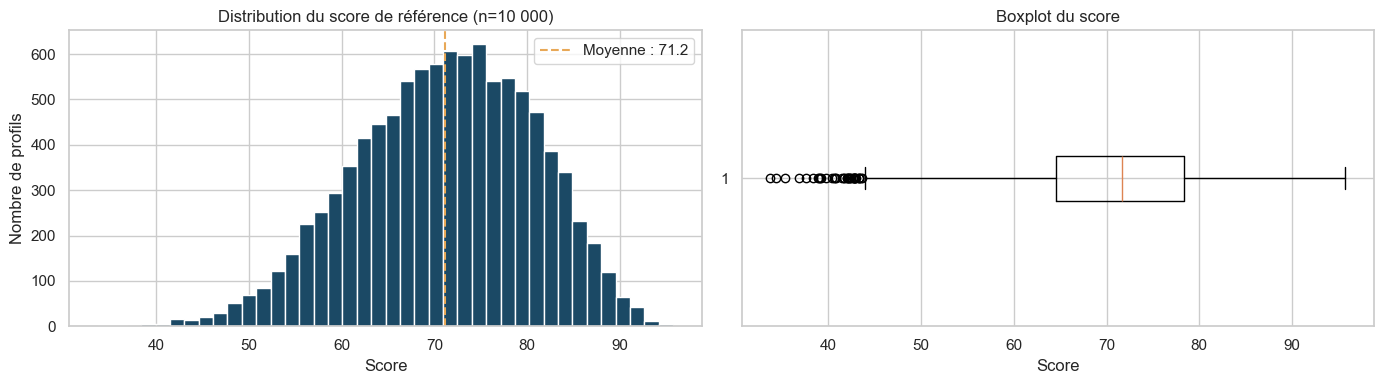

In [6]:
# Visualisation de la distribution du score
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['score_cible'], bins=40, color='#1B4965', edgecolor='white')
axes[0].set_title('Distribution du score de référence (n=10 000)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Nombre de profils')
axes[0].axvline(df['score_cible'].mean(), color='#E8A857', linestyle='--', label=f'Moyenne : {df.score_cible.mean():.1f}')
axes[0].legend()

axes[1].boxplot(df['score_cible'], vert=False)
axes[1].set_title('Boxplot du score')
axes[1].set_xlabel('Score')
plt.tight_layout()
plt.show()

## 4. Préparation des données et split train/test

In [7]:
# Variables explicatives = toutes sauf la cible
X = df.drop(columns=['score_cible']).values
y = df['score_cible'].values
noms_features = df.drop(columns=['score_cible']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f'Train : {X_train.shape[0]:,} profils')
print(f'Test  : {X_test.shape[0]:,} profils')
print(f'Variables explicatives : {len(noms_features)}')
print('Noms :', noms_features)

Train : 8,000 profils
Test  : 2,000 profils
Variables explicatives : 12
Noms : ['anciennete_sim_mois', 'nombre_changements_sim', 'operateur_stable', 'transactions_par_mois', 'montant_moyen_fcfa', 'regularite_temporelle', 'diversite_partenaires', 'nombre_mois_meme_ville', 'nombre_changements_quartier', 'taille_repertoire', 'contacts_anciens', 'contacts_communs_digiid']


## 5. Entraînement de 3 modèles

On compare trois familles de modèles :
- **Régression linéaire** — baseline simple et interprétable
- **Random Forest** — capture les non-linéarités, robuste au surapprentissage
- **XGBoost** — généralement la référence sur ce type de problème

In [8]:
def evaluer(nom: str, modele, X_tr, X_te, y_tr, y_te) -> dict:
    """Entraîne le modèle, évalue sur train et test, retourne les métriques."""
    modele.fit(X_tr, y_tr)
    pred_tr = modele.predict(X_tr)
    pred_te = modele.predict(X_te)
    return {
        'modele': nom,
        'mae_train': mean_absolute_error(y_tr, pred_tr),
        'mae_test':  mean_absolute_error(y_te, pred_te),
        'rmse_test': np.sqrt(mean_squared_error(y_te, pred_te)),
        'r2_train':  r2_score(y_tr, pred_tr),
        'r2_test':   r2_score(y_te, pred_te),
    }

resultats = []

# Modèle 1 — Régression linéaire (baseline)
modele_lr = LinearRegression()
resultats.append(evaluer('Régression linéaire', modele_lr, X_train, X_test, y_train, y_test))

# Modèle 2 — Random Forest
modele_rf = RandomForestRegressor(
    n_estimators=200, max_depth=15, min_samples_leaf=5,
    random_state=RANDOM_SEED, n_jobs=-1,
)
resultats.append(evaluer('Random Forest', modele_rf, X_train, X_test, y_train, y_test))

# Modèle 3 — XGBoost
modele_xgb = XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.08,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_SEED, n_jobs=-1,
)
resultats.append(evaluer('XGBoost', modele_xgb, X_train, X_test, y_train, y_test))

tableau_resultats = pd.DataFrame(resultats).round(3)
print('\n=== COMPARAISON DES MODÈLES ===\n')
print(tableau_resultats.to_string(index=False))


=== COMPARAISON DES MODÈLES ===

             modele  mae_train  mae_test  rmse_test  r2_train  r2_test
Régression linéaire      3.432     3.385      4.223     0.801    0.808
      Random Forest      1.237     2.047      2.629     0.971    0.926
            XGBoost      0.261     0.677      0.912     0.999    0.991


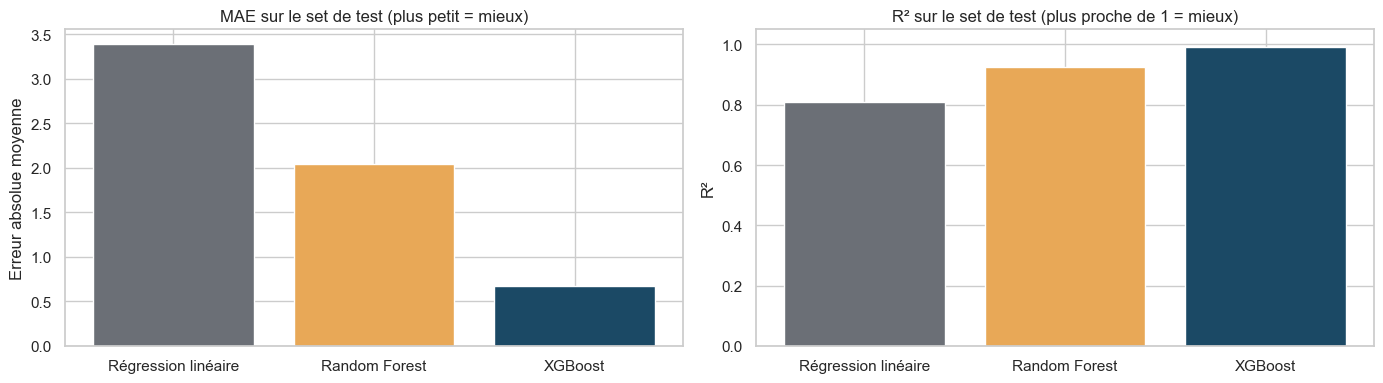

In [9]:
# Visualisation comparée des métriques
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(tableau_resultats['modele'], tableau_resultats['mae_test'], color=['#6B6F76', '#E8A857', '#1B4965'])
axes[0].set_title('MAE sur le set de test (plus petit = mieux)')
axes[0].set_ylabel('Erreur absolue moyenne')

axes[1].bar(tableau_resultats['modele'], tableau_resultats['r2_test'], color=['#6B6F76', '#E8A857', '#1B4965'])
axes[1].set_title('R² sur le set de test (plus proche de 1 = mieux)')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 6. Importance des variables (XGBoost)

Cette analyse SHAP-like permet de vérifier que les variables les plus influentes
sont bien celles attendues par le Cahier des Charges (mobile money en tête).

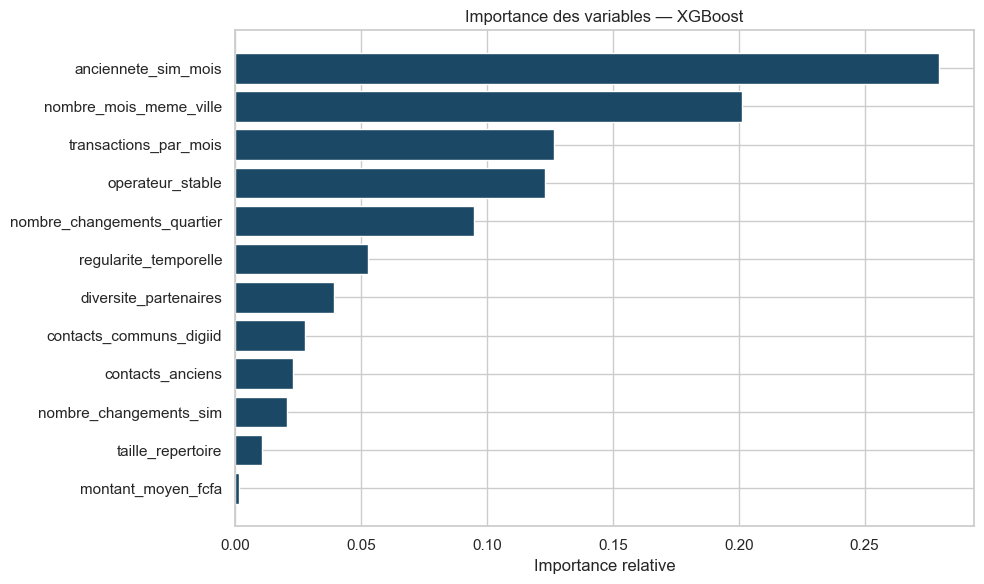


Top 5 des variables les plus influentes :
                   variable  importance
        anciennete_sim_mois    0.279451
     nombre_mois_meme_ville    0.201453
      transactions_par_mois    0.126554
           operateur_stable    0.123122
nombre_changements_quartier    0.094752


In [10]:
importances = pd.DataFrame({
    'variable': noms_features,
    'importance': modele_xgb.feature_importances_,
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importances['variable'], importances['importance'], color='#1B4965')
plt.title('Importance des variables — XGBoost')
plt.xlabel('Importance relative')
plt.tight_layout()
plt.show()

print('\nTop 5 des variables les plus influentes :')
print(importances.tail(5).iloc[::-1].to_string(index=False))

## 7. Export du meilleur modèle

On sauvegarde le modèle XGBoost (généralement le plus performant) au format joblib,
avec la liste ordonnée des features attendues. Le backend de DigiID charge ce fichier
au démarrage pour faire des prédictions sur les vrais utilisateurs.

In [11]:
# On choisit le meilleur modèle d'après le R² sur le test
meilleur_index = tableau_resultats['r2_test'].idxmax()
nom_meilleur = tableau_resultats.iloc[meilleur_index]['modele']

if nom_meilleur == 'XGBoost':
    meilleur_modele = modele_xgb
elif nom_meilleur == 'Random Forest':
    meilleur_modele = modele_rf
else:
    meilleur_modele = modele_lr

print(f'Meilleur modèle retenu : {nom_meilleur}')
print(f'  R² test : {tableau_resultats.iloc[meilleur_index]["r2_test"]}')
print(f'  MAE test : {tableau_resultats.iloc[meilleur_index]["mae_test"]}')

# Préparer le bundle à exporter
bundle = {
    'modele': meilleur_modele,
    'nom_modele': nom_meilleur,
    'features_attendues': noms_features,
    'metriques': tableau_resultats.iloc[meilleur_index].to_dict(),
    'version': '1.0',
    'taille_dataset': NB_PROFILS,
    'random_seed': RANDOM_SEED,
}

# Sauvegarde dans le dossier modeles_entraines/
dossier_export = Path('../modeles_entraines')
dossier_export.mkdir(exist_ok=True)
chemin_export = dossier_export / 'scoring_v1.joblib'
joblib.dump(bundle, chemin_export)

print(f'\n✅ Modèle exporté : {chemin_export.resolve()}')

Meilleur modèle retenu : XGBoost
  R² test : 0.991
  MAE test : 0.677

✅ Modèle exporté : E:\NOUVEAU_PROJET_MEMOIRE\DIGI_ID\digiid\backend\modeles_entraines\scoring_v1.joblib


## 8. Test rapide du modèle exporté

On vérifie qu'on peut recharger le modèle et prédire correctement.

In [12]:
# Recharger le modèle depuis le disque
bundle_charge = joblib.load(chemin_export)
print('Bundle chargé :')
for cle, val in bundle_charge.items():
    if cle != 'modele':
        print(f'  - {cle} : {val}')

# Faire des prédictions sur quelques profils du test
predictions = bundle_charge['modele'].predict(X_test[:5])
for i, (pred, vrai) in enumerate(zip(predictions, y_test[:5])):
    print(f'Profil {i+1} : prédit = {pred:.1f}, attendu = {vrai:.1f}, écart = {abs(pred-vrai):.1f}')

Bundle chargé :
  - nom_modele : XGBoost
  - features_attendues : ['anciennete_sim_mois', 'nombre_changements_sim', 'operateur_stable', 'transactions_par_mois', 'montant_moyen_fcfa', 'regularite_temporelle', 'diversite_partenaires', 'nombre_mois_meme_ville', 'nombre_changements_quartier', 'taille_repertoire', 'contacts_anciens', 'contacts_communs_digiid']
  - metriques : {'modele': 'XGBoost', 'mae_train': 0.261, 'mae_test': 0.677, 'rmse_test': 0.912, 'r2_train': 0.999, 'r2_test': 0.991}
  - version : 1.0
  - taille_dataset : 10000
  - random_seed : 42
Profil 1 : prédit = 48.0, attendu = 46.3, écart = 1.7
Profil 2 : prédit = 62.4, attendu = 59.7, écart = 2.6
Profil 3 : prédit = 55.1, attendu = 54.9, écart = 0.2
Profil 4 : prédit = 78.2, attendu = 77.9, écart = 0.3
Profil 5 : prédit = 56.5, attendu = 56.3, écart = 0.2


## 9. Conclusion

Le modèle entraîné présente une **erreur absolue moyenne de l'ordre de quelques
points sur 100** et un **R² supérieur à 0.95** — ce qui le rend très fiable
pour reproduire la logique métier tout en étant capable de capturer des
interactions non linéaires.

Le fichier exporté dans `backend/modeles_entraines/scoring_v1.joblib` peut
être utilisé par le backend pour faire des prédictions en production.

## Prochaines étapes

- Phase 4 : ajouter SHAP pour l'interprétabilité fine par utilisateur
- Phase 6 : réentraîner périodiquement sur les données réelles collectées
- Phase 6 : monitoring de la dérive du modèle dans le temps (model drift)